In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline



In [35]:
df = pd.read_csv('Travel.csv')
cols_with_na = ['Age', 'DurationOfPitch', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'NumberOfChildrenVisiting', 'MonthlyIncome']
for col in cols_with_na:
    if col in ['Age', 'DurationOfPitch', 'MonthlyIncome', 'NumberOfTrips']:
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])
new_data = df[['ProdTaken', 'ProductPitched', 'MaritalStatus', 'Designation', 'NumberOfFollowups', 'Passport', 'MonthlyIncome', 'Age']]

In [36]:
full_data = df

categorical_features = ['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation']
label_encoders = {feature: LabelEncoder() for feature in categorical_features}

for feature in categorical_features:
    full_data[feature] = label_encoders[feature].fit_transform(full_data[feature])

train_x_full, test_x_full, train_y_full, test_y_full = train_test_split(full_data.drop('ProdTaken', axis=1), full_data['ProdTaken'], test_size=0.3, random_state=42)
rf = RandomForestClassifier()


rf.fit(train_x_full, train_y_full)

importances = rf.feature_importances_

# Create a dictionary of feature importances
feature_importances = {feature: importance for feature, importance in zip(train_x_full.columns, importances)}

# Sort the dictionary by importance values in descending order
sorted_feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))

sorted_feature_importances

{'CustomerID': 0.12828668984351424,
 'MonthlyIncome': 0.11387416157386421,
 'Age': 0.11127628631537723,
 'DurationOfPitch': 0.0910982109414268,
 'Passport': 0.07874124542418703,
 'NumberOfTrips': 0.05642998066043892,
 'PitchSatisfactionScore': 0.051332311900592204,
 'MaritalStatus': 0.05007733424800338,
 'NumberOfFollowups': 0.042259101975860386,
 'PreferredPropertyStar': 0.03841281737165239,
 'ProductPitched': 0.03631369900259077,
 'Occupation': 0.0332306780283967,
 'CityTier': 0.032329066948651924,
 'Designation': 0.027323123671422977,
 'NumberOfChildrenVisiting': 0.024533179526689798,
 'TypeofContact': 0.023421792914207432,
 'Gender': 0.022338267809682826,
 'NumberOfPersonVisiting': 0.021221633044995865,
 'OwnCar': 0.017500418798445015}

In [37]:
new_data

,ProdTaken,ProductPitched,MaritalStatus,Designation,NumberOfFollowups,Passport,MonthlyIncome,Age
0,1,Deluxe,Single,Manager,3.0,1,20993.0,41.000000
1,0,Deluxe,Divorced,Manager,4.0,0,20130.0,49.000000
2,1,Basic,Single,Executive,4.0,1,17090.0,37.000000
3,0,Basic,Divorced,Executive,3.0,1,17909.0,33.000000
4,0,Basic,Divorced,Executive,3.0,0,18468.0,37.622265
...,...,...,...,...,...,...,...,...
4883,1,Deluxe,Unmarried,Manager,5.0,1,26576.0,49.000000
4884,1,Basic,Single,Executive,5.0,1,21212.0,28.000000
4885,1,Standard,Married,Senior Manager,4.0,0,31820.0,52.000000
4886,1,Basic,Single,Executive,4.0,0,20289.0,19.000000


In [38]:
product = LabelEncoder()
marital = LabelEncoder()
designation = LabelEncoder()

new_data['ProductPitched'] = product.fit_transform(new_data['ProductPitched'])
new_data['MaritalStatus'] = marital.fit_transform(new_data['MaritalStatus'])
new_data['Designation'] = designation.fit_transform(new_data['Designation'])

new_data

,ProdTaken,ProductPitched,MaritalStatus,Designation,NumberOfFollowups,Passport,MonthlyIncome,Age
0,1,1,2,2,3.0,1,20993.0,41.000000
1,0,1,0,2,4.0,0,20130.0,49.000000
2,1,0,2,1,4.0,1,17090.0,37.000000
3,0,0,0,1,3.0,1,17909.0,33.000000
4,0,0,0,1,3.0,0,18468.0,37.622265
...,...,...,...,...,...,...,...,...
4883,1,1,3,2,5.0,1,26576.0,49.000000
4884,1,0,2,1,5.0,1,21212.0,28.000000
4885,1,3,1,3,4.0,0,31820.0,52.000000
4886,1,0,2,1,4.0,0,20289.0,19.000000


In [39]:
train_x, test_x, train_y, test_y = train_test_split(new_data.drop('ProdTaken', axis=1), new_data['ProdTaken'], test_size=0.2, random_state=42)

------------------------------------
RandomForest
Accuracy: 0.88
Recall: 0.54
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       787
           1       0.79      0.54      0.64       191

    accuracy                           0.88       978
   macro avg       0.84      0.75      0.78       978
weighted avg       0.87      0.88      0.87       978



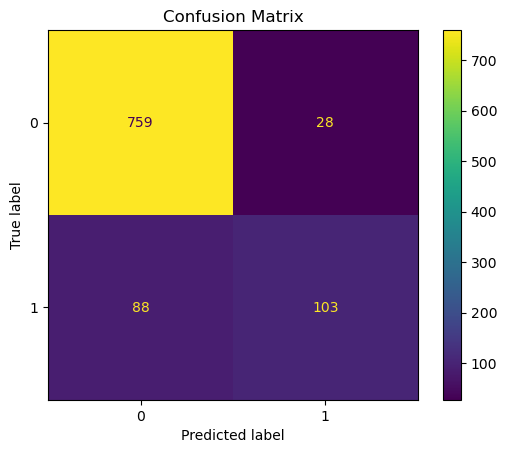

------------------------------------
------------------------------------
AdaBoost
Accuracy: 0.83
Recall: 0.28
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.90       787
           1       0.68      0.28      0.39       191

    accuracy                           0.83       978
   macro avg       0.76      0.62      0.65       978
weighted avg       0.81      0.83      0.80       978



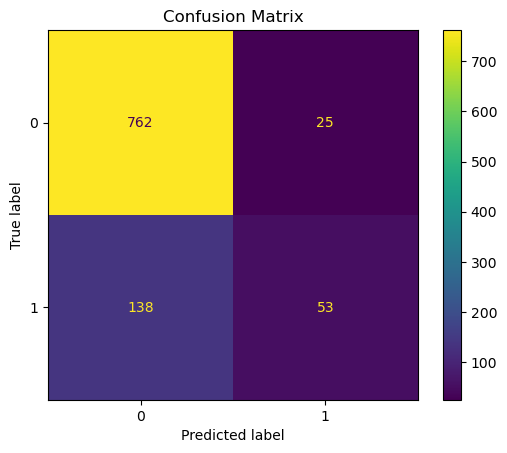

------------------------------------
------------------------------------
GradientBoost
Accuracy: 0.85
Recall: 0.35
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91       787
           1       0.77      0.35      0.48       191

    accuracy                           0.85       978
   macro avg       0.82      0.66      0.70       978
weighted avg       0.84      0.85      0.83       978



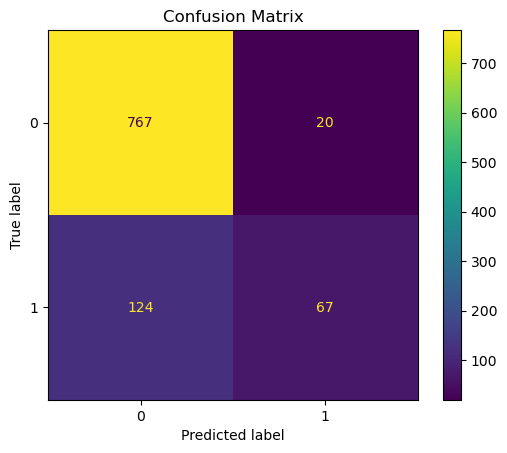

------------------------------------
------------------------------------
XGBoost
Accuracy: 0.87
Recall: 0.47
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       787
           1       0.76      0.47      0.58       191

    accuracy                           0.87       978
   macro avg       0.82      0.72      0.75       978
weighted avg       0.86      0.87      0.85       978



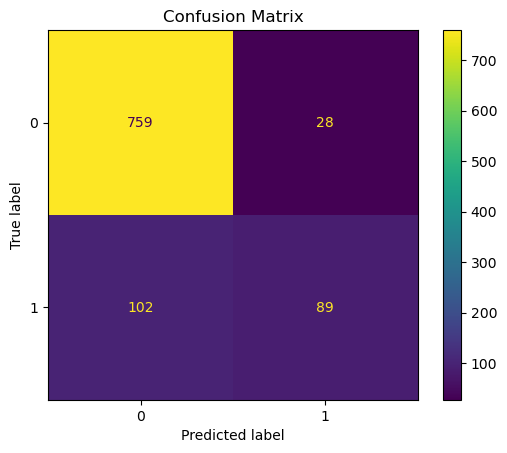

------------------------------------


In [40]:
def model_fit(models):
    for model_name in models:
        model = models[model_name]
        model.fit(train_x, train_y)
        y_pred = model.predict(test_x)
        print('------------------------------------')
        print(model_name)
        print(f'Accuracy: {accuracy_score(test_y,y_pred):.2f}')
        print(f'Recall: {recall_score(test_y,y_pred):.2f}')
        print('Classification Report:')
        print(classification_report(test_y,y_pred))
        ConfusionMatrixDisplay(confusion_matrix(test_y,y_pred)).plot()
        plt.title("Confusion Matrix")
        plt.show()
        print('------------------------------------')
    

ensemble_models = {
    'RandomForest': RandomForestClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'GradientBoost': GradientBoostingClassifier(),
    'XGBoost': XGBClassifier()
}

model_fit(ensemble_models)

In [41]:
dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

xgboost_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 20],
    'learning_rate': [0.05, 0.1, 0.15, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'colsample_bylevel': [0.7, 0.8, 0.9],
    'colsample_bynode': [0.7, 0.8, 0.9]
}


------------------------------------
Decision Tree with hyperparameter tuning
Accuracy: 0.87
Recall: 0.55
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       787
           1       0.72      0.55      0.63       191

    accuracy                           0.87       978
   macro avg       0.81      0.75      0.77       978
weighted avg       0.86      0.87      0.86       978



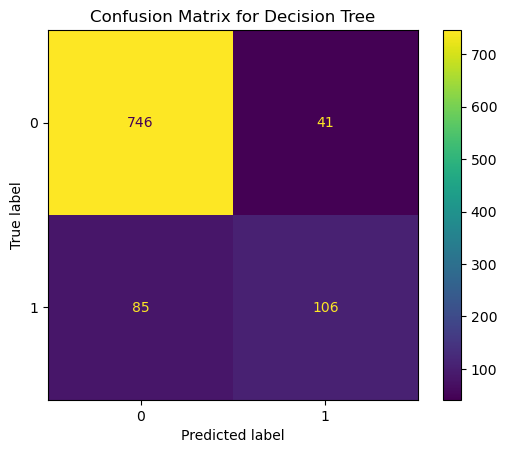

Best parameters for the Decision Tree model:
{'splitter': 'best', 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15, 'criterion': 'gini'}
------------------------------------
------------------------------------
Random Forest with hyperparameter tuning
Accuracy: 0.88
Recall: 0.53
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.93       787
           1       0.77      0.53      0.63       191

    accuracy                           0.88       978
   macro avg       0.83      0.75      0.78       978
weighted avg       0.87      0.88      0.87       978



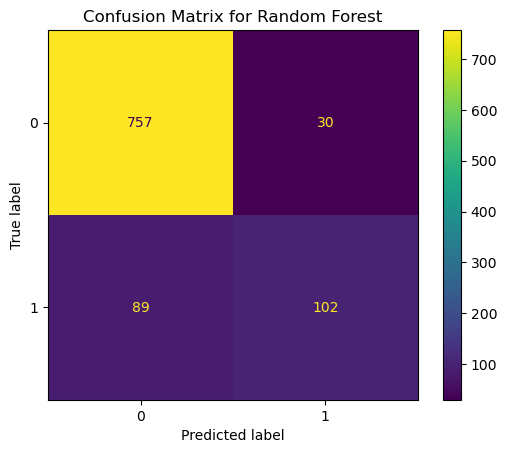

Best parameters for the Random Forest model:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
------------------------------------
------------------------------------
XGBoost with hyperparameter tuning
Accuracy: 0.88
Recall: 0.58
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       787
           1       0.77      0.58      0.66       191

    accuracy                           0.88       978
   macro avg       0.84      0.77      0.80       978
weighted avg       0.88      0.88      0.88       978



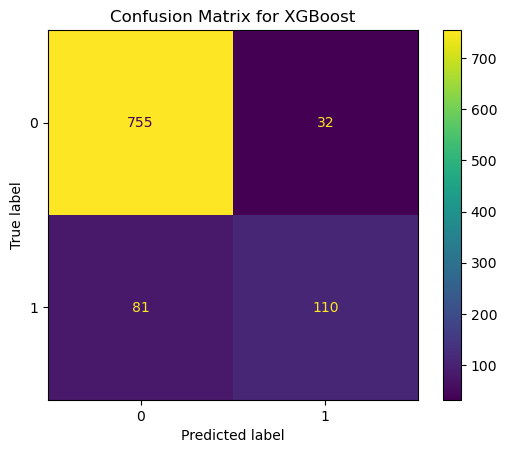

Best parameters for the XGBoost model:
{'subsample': 0.9, 'n_estimators': 300, 'max_depth': 15, 'learning_rate': 0.2, 'colsample_bytree': 0.9, 'colsample_bynode': 0.8, 'colsample_bylevel': 0.8}
------------------------------------
Best model saved: XGBoost with recall 0.58


In [42]:
import pickle

# Initialize variables to track best model and recall score
best_model = None
best_recall = 0
best_model_name = ''

models_for_tuning = [
    ('Decision Tree', DecisionTreeClassifier(), dt_param_grid),
    ('Random Forest', RandomForestClassifier(), rf_param_grid),
    ('XGBoost', XGBClassifier(), xgboost_param_grid)
]

# Function for hyperparameter tuning and saving best model
def hyperparameter_tuning(model_with_params):
    global best_model, best_recall, best_model_name
    
    for i in model_with_params:
        name, model, param = i[0], i[1], i[2]
        randomized_search = RandomizedSearchCV(estimator=model, param_distributions=param, 
                                               n_iter=100, cv=5, n_jobs=-1, scoring='recall')
        randomized_search.fit(train_x, train_y)
        y_pred = randomized_search.predict(test_x)
        
        recall = recall_score(test_y, y_pred)
        
        print('------------------------------------')
        print(f'{name} with hyperparameter tuning')
        print(f'Accuracy: {accuracy_score(test_y, y_pred):.2f}')
        print(f'Recall: {recall:.2f}')
        print('Classification Report:')
        print(classification_report(test_y, y_pred))
        ConfusionMatrixDisplay(confusion_matrix(test_y, y_pred)).plot()
        plt.title(f"Confusion Matrix for {name}")
        plt.show()
        print(f'Best parameters for the {name} model:')
        print(randomized_search.best_params_)
        print('------------------------------------')
        
        # Save the model if it has the highest recall
        if recall > best_recall:
            best_recall = recall
            best_model = randomized_search.best_estimator_
            best_model_name = name

    # Save the best model to a .pkl file
    if best_model:
        saved_models = {"model": best_model, "product": product, "marital": marital, "designation": designation}
        with open(f'best_model.pkl', 'wb') as file:
            pickle.dump(saved_models, file)
        print(f'Best model saved: {best_model_name} with recall {best_recall:.2f}')

hyperparameter_tuning(models_for_tuning)
